# Email Spam Detection Using Python

## Import Required Libraries

In [2]:
# Import required libraries

import pandas as pd
import numpy as np
import re
import string

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

## Load the Dataset

In [3]:
df = pd.read_csv("C:/Users/bhanu/OneDrive/Desktop/OIBSIP/task_4/spam.csv", encoding="latin1")

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## Check Dataset Information

In [4]:
df.shape

(5572, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [6]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

## Clean the Dataset

In [7]:
df = df.iloc[:, :2]

# Rename columns
df.columns = ["label", "message"]

# Display dataset again
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Basic Dataset Information

In [8]:
print("Dataset shape:", df.shape)

Dataset shape: (5572, 2)


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [10]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(403)

In [12]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (5169, 2)


## Class Distribution

The class distribution helps us understand how many messages are spam and how many are ham. This is important because spam datasets are usually imbalanced, meaning ham messages are often much higher than spam messages.

## Check Spam and Ham Count

In [13]:
class_counts = df["label"].value_counts()
class_percentages = df["label"].value_counts(normalize=True) * 100

distribution = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentages.round(2)
})

distribution

,Count,Percentage
label,,
ham,4516,87.37
spam,653,12.63


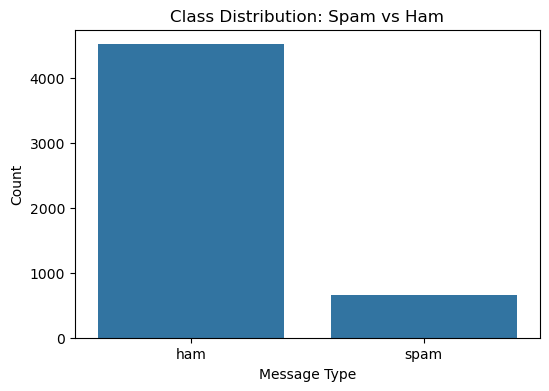

In [14]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="label")
plt.title("Class Distribution: Spam vs Ham")
plt.xlabel("Message Type")
plt.ylabel("Count")
plt.show()

## Text Preprocessing

Text preprocessing is required before applying machine learning models.  
The following preprocessing steps are applied:

1. Convert text to lowercase
2. Remove punctuation
3. Remove numbers
4. Remove extra spaces
5. Remove common stopwords


##  Define basic stopwords manually

In [15]:


stopwords = set([
    "i", "me", "my", "myself", "we", "our", "ours", "ourselves",
    "you", "your", "yours", "yourself", "yourselves",
    "he", "him", "his", "himself", "she", "her", "hers", "herself",
    "it", "its", "itself", "they", "them", "their", "theirs", "themselves",
    "what", "which", "who", "whom", "this", "that", "these", "those",
    "am", "is", "are", "was", "were", "be", "been", "being",
    "have", "has", "had", "having", "do", "does", "did", "doing",
    "a", "an", "the", "and", "but", "if", "or", "because", "as",
    "until", "while", "of", "at", "by", "for", "with", "about",
    "against", "between", "into", "through", "during", "before",
    "after", "above", "below", "to", "from", "up", "down", "in",
    "out", "on", "off", "over", "under", "again", "further",
    "then", "once", "here", "there", "when", "where", "why",
    "how", "all", "any", "both", "each", "few", "more", "most",
    "other", "some", "such", "no", "nor", "not", "only", "own",
    "same", "so", "than", "too", "very", "can", "will", "just"
])

##  Text cleaning function

In [16]:

def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    
    # Remove punctuation
    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)
    
    # Remove numbers
    text = re.sub(r"\d+", " ", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    # Remove stopwords
    words = text.split()
    words = [word for word in words if word not in stopwords]
    
    return " ".join(words)

## Apply text preprocessing

In [17]:


df["clean_message"] = df["message"].apply(clean_text)

df[["message", "clean_message"]].head()

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah don t think goes usf lives around though


## Convert Labels into Numbers

In [18]:
df["label_encoded"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

df.head()

,label,message,clean_message,label_encoded
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...,0
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...,1
3,ham,U dun say so early hor... U c already then say...,u dun say early hor u c already say,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah don t think goes usf lives around though,0


## TF-IDF Vectorizer

TF-IDF stands for Term Frequency-Inverse Document Frequency.

It measures how important a word is in a message compared to the entire dataset.

- Term Frequency measures how often a word appears in a message.
- Inverse Document Frequency reduces the importance of words that appear too commonly across many messages.
- Words that are frequent in one message but rare across the dataset get higher importance.

TF-IDF is useful in spam detection because spam messages often contain important repeated words such as "free", "win", "cash", "prize", and "claim".

## Train-Test Split

In [19]:
X = df["clean_message"]
y = df["label_encoded"]

## Split the Dataset

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

Training data size: (4135,)
Testing data size: (1034,)


## Convert Text into Numbers Using TF-IDF

In [21]:
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF training shape:", X_train_tfidf.shape)
print("TF-IDF testing shape:", X_test_tfidf.shape)

TF-IDF training shape: (4135, 5000)
TF-IDF testing shape: (1034, 5000)


## Train Classifier 1: Multinomial Naive Bayes

In [22]:
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_predictions = nb_model.predict(X_test_tfidf)

## Train Classifier 2: Logistic Regression

In [23]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_tfidf, y_train)

lr_predictions = lr_model.predict(X_test_tfidf)

## Train Classifier 3: SVM

In [25]:
svm_model = LinearSVC()

svm_model.fit(X_train_tfidf, y_train)

svm_predictions = svm_model.predict(X_test_tfidf)

## Model Evaluation Function

In [26]:
def evaluate_model(model_name, y_test, y_pred):
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f"Model: {model_name}")
    print("-" * 40)
    print("Accuracy:", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall:", round(recall, 4))
    print("F1 Score:", round(f1, 4))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

## Evaluate Naive Bayes

In [27]:
evaluate_model("Multinomial Naive Bayes", y_test, nb_predictions)

Model: Multinomial Naive Bayes
----------------------------------------
Accuracy: 0.9662
Precision: 0.9898
Recall: 0.7405
F1 Score: 0.8472

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       903
           1       0.99      0.74      0.85       131

    accuracy                           0.97      1034
   macro avg       0.98      0.87      0.91      1034
weighted avg       0.97      0.97      0.96      1034



## Confusion matrix for Naive Bayes

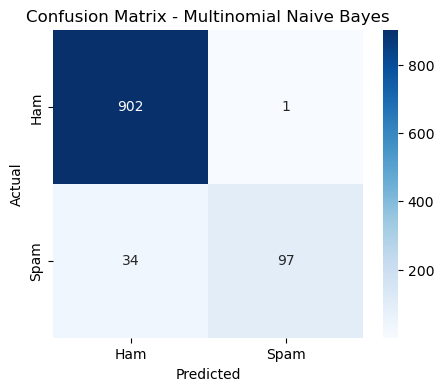

In [28]:
nb_cm = confusion_matrix(y_test, nb_predictions)

plt.figure(figsize=(5, 4))
sns.heatmap(nb_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Ham", "Spam"],
            yticklabels=["Ham", "Spam"])

plt.title("Confusion Matrix - Multinomial Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Evaluate Logistic Regression

In [30]:
evaluate_model("Logistic Regression", y_test, lr_predictions)

Model: Logistic Regression
----------------------------------------
Accuracy: 0.9594
Precision: 0.9785
Recall: 0.6947
F1 Score: 0.8125

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       903
           1       0.98      0.69      0.81       131

    accuracy                           0.96      1034
   macro avg       0.97      0.85      0.89      1034
weighted avg       0.96      0.96      0.96      1034



## Confusion matrix for Logistic Regression

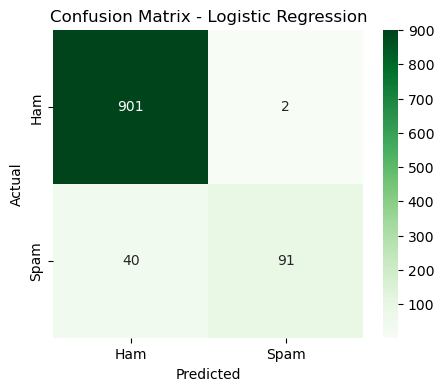

In [31]:
lr_cm = confusion_matrix(y_test, lr_predictions)

plt.figure(figsize=(5, 4))
sns.heatmap(lr_cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Ham", "Spam"],
            yticklabels=["Ham", "Spam"])

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Evaluate SVM

In [32]:
evaluate_model("Support Vector Machine", y_test, svm_predictions)

Model: Support Vector Machine
----------------------------------------
Accuracy: 0.9807
Precision: 0.9744
Recall: 0.8702
F1 Score: 0.9194

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       903
           1       0.97      0.87      0.92       131

    accuracy                           0.98      1034
   macro avg       0.98      0.93      0.95      1034
weighted avg       0.98      0.98      0.98      1034



##  Confusion matrix for SVM

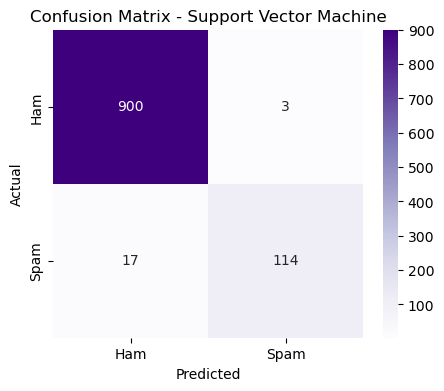

In [33]:
svm_cm = confusion_matrix(y_test, svm_predictions)

plt.figure(figsize=(5, 4))
sns.heatmap(svm_cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Ham", "Spam"],
            yticklabels=["Ham", "Spam"])

plt.title("Confusion Matrix - Support Vector Machine")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Compare Model Results

In [34]:
results = pd.DataFrame({
    "Model": [
        "Multinomial Naive Bayes",
        "Logistic Regression",
        "Support Vector Machine"
    ],
    "Accuracy": [
        accuracy_score(y_test, nb_predictions),
        accuracy_score(y_test, lr_predictions),
        accuracy_score(y_test, svm_predictions)
    ],
    "Precision": [
        precision_score(y_test, nb_predictions),
        precision_score(y_test, lr_predictions),
        precision_score(y_test, svm_predictions)
    ],
    "Recall": [
        recall_score(y_test, nb_predictions),
        recall_score(y_test, lr_predictions),
        recall_score(y_test, svm_predictions)
    ],
    "F1 Score": [
        f1_score(y_test, nb_predictions),
        f1_score(y_test, lr_predictions),
        f1_score(y_test, svm_predictions)
    ]
})

results


,Model,Accuracy,Precision,Recall,F1 Score
0,Multinomial Naive Bayes,0.966151,0.989796,0.740458,0.847162
1,Logistic Regression,0.959381,0.978495,0.694656,0.812500
2,Support Vector Machine,0.980658,0.974359,0.870229,0.919355


## Plot model comparison

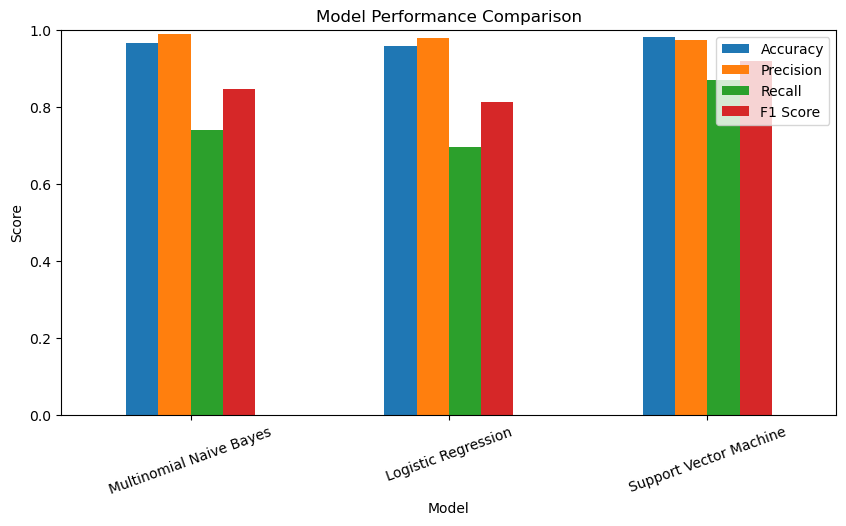

In [36]:


results.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

## Why Recall Is Important in Spam Detection

Recall is especially important in spam detection because it measures how many actual spam messages are correctly identified by the model.

If recall is low, many spam messages may be incorrectly classified as ham. This is risky because harmful emails such as phishing links, scam messages, fake offers, or malware-related content may reach the user's inbox.

In spam detection, missing a spam email can be more dangerous than wrongly sending one normal email to the spam folder. Therefore, a good spam detection model should try to achieve high recall while also maintaining reasonable precision.

## Separate spam and ham messages

## WordCloud for spam messages

In [40]:
!pip install wordcloud

In [41]:
from wordcloud import WordCloud

In [42]:
spam_text = " ".join(df[df["label"] == "spam"]["clean_message"])
ham_text = " ".join(df[df["label"] == "ham"]["clean_message"])

## WordCloud for spam messages

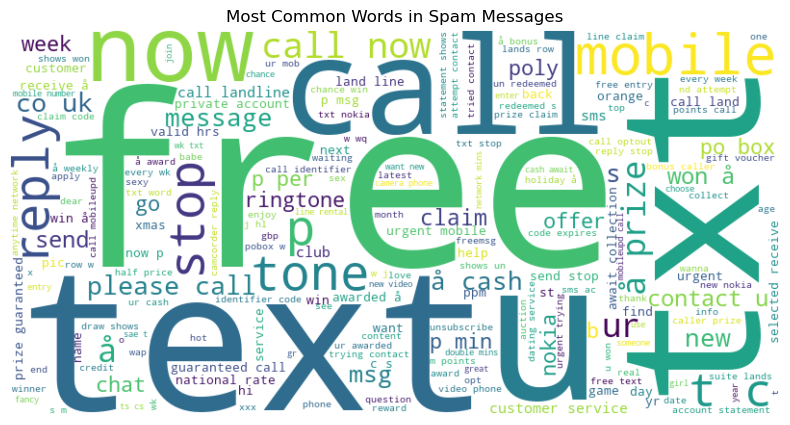

In [43]:
spam_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(spam_text)

plt.figure(figsize=(10, 5))
plt.imshow(spam_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Spam Messages")
plt.show()

## WordCloud for ham messages

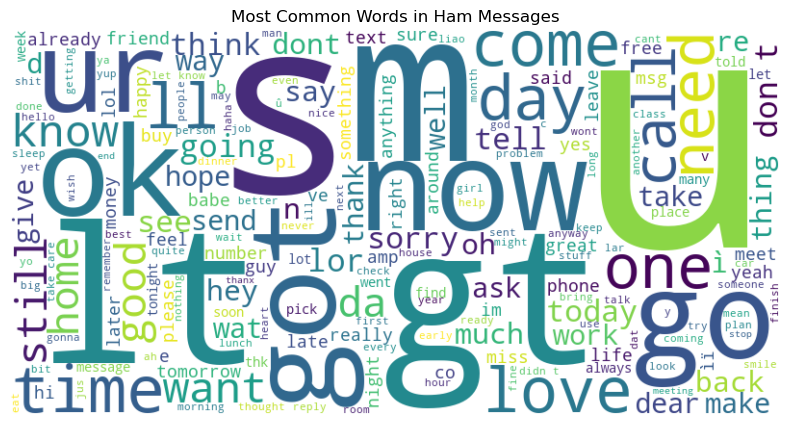

In [44]:
ham_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(ham_text)

plt.figure(figsize=(10, 5))
plt.imshow(ham_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Ham Messages")
plt.show()

## Test with Custom Messages

In [45]:
def predict_message(message, model):
    cleaned_message = clean_text(message)
    vectorized_message = tfidf.transform([cleaned_message])
    prediction = model.predict(vectorized_message)[0]
    
    if prediction == 1:
        return "Spam"
    else:
        return "Ham"

## Test sample spam message

In [46]:
sample_1 = "Congratulations! You have won a free prize. Click here to claim now."
print(predict_message(sample_1, lr_model))

Spam


## Test sample ham message

In [47]:
sample_2 = "Hi, are we still meeting for lunch tomorrow?"
print(predict_message(sample_2, lr_model))

Ham


## Conclusion

In this project, an email spam detection system was built using Natural Language Processing and Machine Learning.

The text data was cleaned using preprocessing techniques such as lowercase conversion, punctuation removal, number removal, and stopword removal. TF-IDF Vectorizer was used to convert text into numerical features.

Three machine learning models were trained and tested:
1. Multinomial Naive Bayes
2. Logistic Regression
3. Support Vector Machine

The models were evaluated using accuracy, precision, recall, F1-score, and confusion matrix. Recall was considered especially important because spam detection should reduce the number of harmful spam messages reaching the user's inbox.

Overall, this project demonstrates how NLP and machine learning can be used to automatically classify spam and ham messages.